In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pathlib
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers

from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras import optimizers

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/Data"
type(data_dir)

str

In [4]:
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib.PosixPath

In [5]:
data_dir.glob("*")

<generator object Path.glob at 0x791110658040>

In [6]:
list(data_dir.glob("*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Leaf smut'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Brown spot')]

In [7]:
list(data_dir.glob("Bacterial leaf blight/*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0377.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0378.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0379.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0365.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0373.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0374.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0375.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0376.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0380.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bacterial leaf blight/DSC_0382.JPG'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Data/Bact

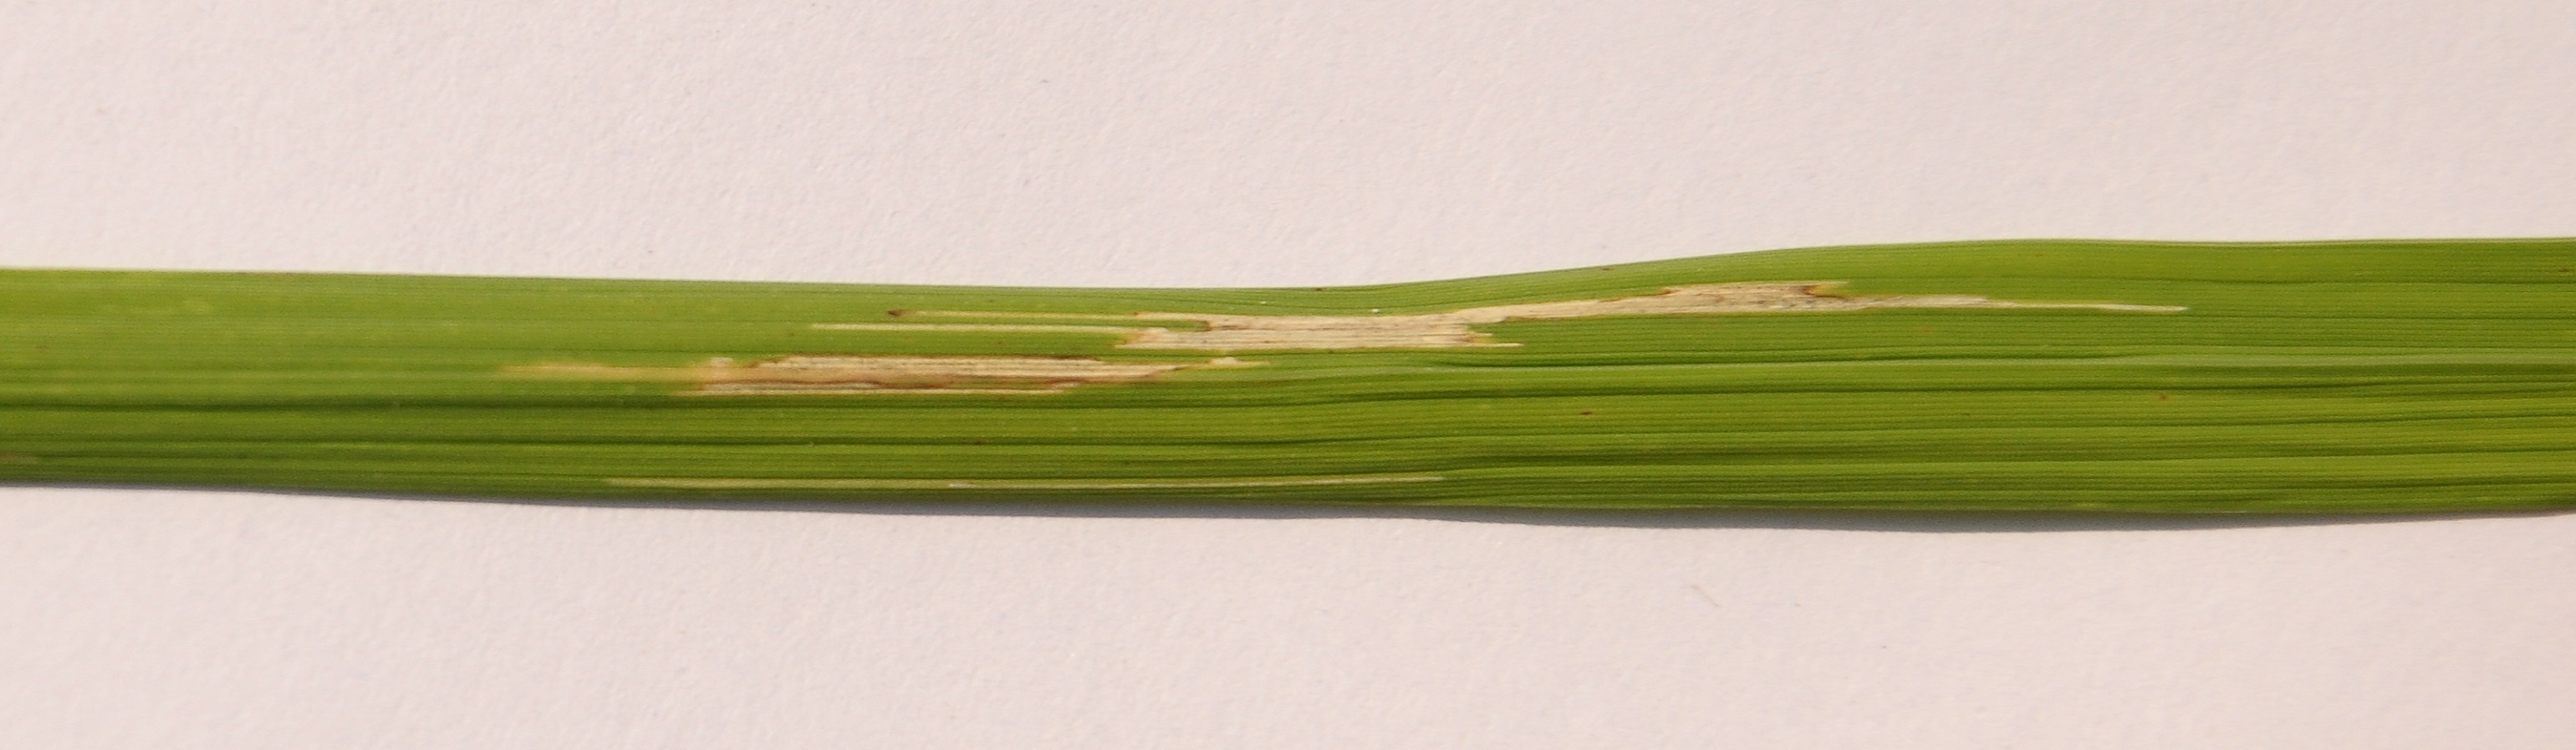

In [8]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("Bacterial leaf blight/*"))[10]))

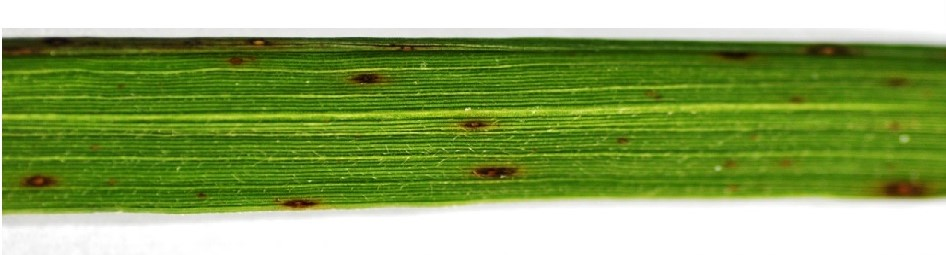

In [9]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("Leaf smut/*"))[20]))

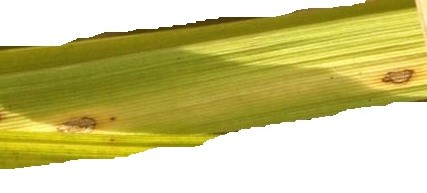

In [10]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("Brown spot/*"))[30]))

In [11]:
print(len(list(data_dir.glob("Bacterial leaf blight/*"))))
print(len(list(data_dir.glob("Leaf smut/*"))))
print(len(list(data_dir.glob("Brown spot/*"))))

40
39
40


In [12]:
40+39+40

119

In [13]:
diseases_images_dict = {
    'Bacterial_leaf_blight': list(data_dir.glob('Bacterial leaf blight/*')),
    'Leaf_smut': list(data_dir.glob('Leaf smut/*')),
    'Brown_spot': list(data_dir.glob('Brown spot/*')),
}
diseases_labels_dict = {
    'Bacterial_leaf_blight': 0,
    'Leaf_smut': 1,
    'Brown_spot': 2,
}

In [14]:
X, y = [], []

for disease_name, images in diseases_images_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_img = cv2.resize(img,(224,224))
        # resized_img = resized_img.astype("float32")/255
        resized_img = resized_img.astype("float32")
        X.append(resized_img)
        y.append(diseases_labels_dict[disease_name])

In [15]:
X = np.array(X)
y = np.array(y)

In [16]:
X.shape

(119, 224, 224, 3)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1 ,
    stratify=y ,
    random_state=0
    )

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

In [18]:
# train_datagen = ImageDataGenerator(
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True
# )

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    x_train_final,
    y_train_final,
    batch_size=16,
    shuffle=True
)

In [19]:
# val_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_generator = val_datagen.flow(
    x_val,
    y_val,
    batch_size=16,
    shuffle=False
)

# 1) Simple ANN (Fully Connected Network):-

In [20]:
checkpointer = ModelCheckpoint(
    filepath='rice_leaf_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
ann_model = models.Sequential()

ann_model.add(layers.Flatten(input_shape=(224, 224, 3)))

ann_model.add(layers.Dense(64, activation='relu'))
ann_model.add(layers.Dropout(0.5))

ann_model.add(layers.Dense(32, activation='relu'))
ann_model.add(layers.Dropout(0.3))

ann_model.add(layers.Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,636,035 (36.76 MB)

 Trainable params: 9,636,035 (36.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


“Data generators with augmentation are primarily designed for convolutional neural networks, which can learn spatial transformations. Since ANN models operate on flattened inputs and do not preserve spatial relationships, using image generators with augmentation is not meaningful for ANN. Therefore, ANN models are trained directly on NumPy arrays without augmentation.”

In [ ]:
history = ann_model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    batch_size=16,
    validation_data=(x_val, y_val),
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2,
    shuffle=True
)


Epoch 1/30

Epoch 1: val_loss improved from inf to 1.34028, saving model to rice_leaf_best_model.keras
6/6 - 7s - 1s/step - accuracy: 0.2667 - loss: 6.2930 - val_accuracy: 0.2941 - val_loss: 1.3403 - learning_rate: 1.0000e-04
Epoch 2/30

Epoch 2: val_loss improved from 1.34028 to 1.30062, saving model to rice_leaf_best_model.keras
6/6 - 1s - 111ms/step - accuracy: 0.4000 - loss: 3.3178 - val_accuracy: 0.2941 - val_loss: 1.3006 - learning_rate: 1.0000e-04
Epoch 3/30

Epoch 3: val_loss improved from 1.30062 to 1.08608, saving model to rice_leaf_best_model.keras
6/6 - 1s - 130ms/step - accuracy: 0.3667 - loss: 1.6043 - val_accuracy: 0.4118 - val_loss: 1.0861 - learning_rate: 1.0000e-04
Epoch 4/30

Epoch 4: val_loss did not improve from 1.08608
6/6 - 0s - 21ms/step - accuracy: 0.3556 - loss: 1.1002 - val_accuracy: 0.3529 - val_loss: 1.1007 - learning_rate: 1.0000e-04
Epoch 5/30

Epoch 5: val_loss did not improve from 1.08608
6/6 - 0s - 20ms/step - accuracy: 0.3333 - loss: 1.0986 - val_accu

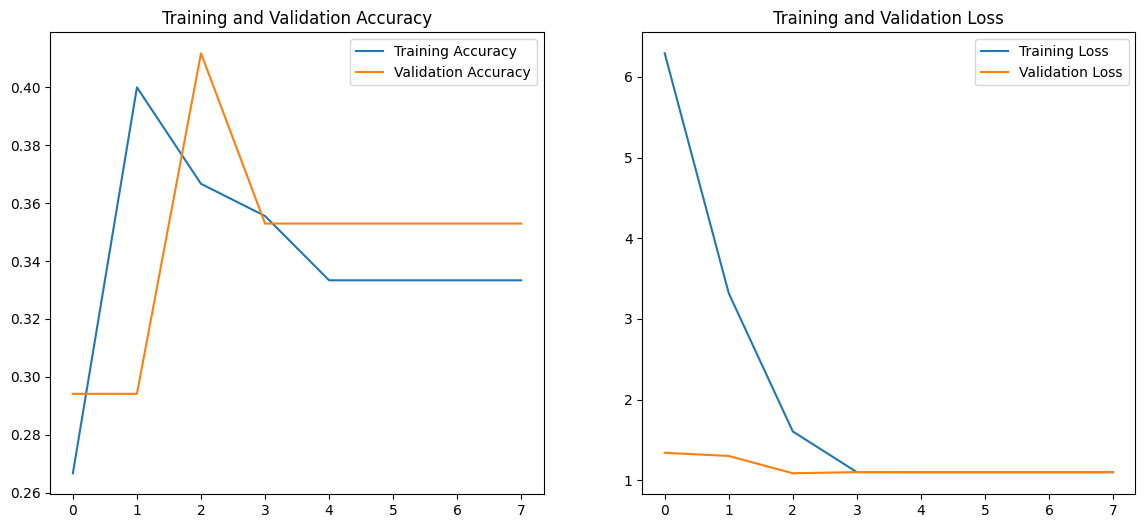

In [ ]:
# Plot training metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
ann_model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - accuracy: 0.5000 - loss: 1.0914


[1.0913642644882202, 0.5]

In [ ]:
y_pred_prob = ann_model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test

print(classification_report(
    y_true,
    y_pred,
    zero_division=0
))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.50      1.00      0.67         4
           2       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.44        12
weighted avg       0.50      0.50      0.44        12



# 2) Custom CNN:-

In [ ]:
cnn_model = models.Sequential()

# Input layer
cnn_model.add(layers.Input(shape=(224, 224, 3)))

# -------- Block 1 --------
cnn_model.add(layers.Conv2D(32, (3,3), activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.20))

# -------- Block 2 --------
cnn_model.add(layers.Conv2D(64, (3,3), activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.25))

# -------- Block 3 --------
cnn_model.add(layers.Conv2D(128, (3,3), activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.30))

# -------- Block 4 --------
cnn_model.add(layers.Conv2D(256, (3,3), activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))
cnn_model.add(layers.Dropout(0.30))

# -------- Classifier --------
cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(3, activation='softmax'))

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │       110,595 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 499,011 (1.90 MB)

 Trainable params: 499,011 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50

Epoch 1: val_loss did not improve from 1.08608
6/6 - 17s - 3s/step - accuracy: 0.3333 - loss: 1.1370 - val_accuracy: 0.2941 - val_loss: 1.1044 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_loss did not improve from 1.08608
6/6 - 2s - 259ms/step - accuracy: 0.2556 - loss: 1.1369 - val_accuracy: 0.2941 - val_loss: 1.1011 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_loss did not improve from 1.08608
6/6 - 2s - 300ms/step - accuracy: 0.4111 - loss: 1.1125 - val_accuracy: 0.2941 - val_loss: 1.0978 - learning_rate: 1.0000e-04
Epoch 4/50

Epoch 4: val_loss did not improve from 1.08608
6/6 - 1s - 196ms/step - accuracy: 0.3778 - loss: 1.0952 - val_accuracy: 0.2941 - val_loss: 1.1021 - learning_rate: 1.0000e-04
Epoch 5/50

Epoch 5: val_loss did not improve from 1.08608
6/6 - 1s - 176ms/step - accuracy: 0.3889 - loss: 1.0890 - val_accuracy: 0.3529 - val_loss: 1.0985 - learning_rate: 1.0000e-04
Epoch 6/50

Epoch 6: val_loss did not improve from 1.08608
6/6 - 1s - 175ms/s

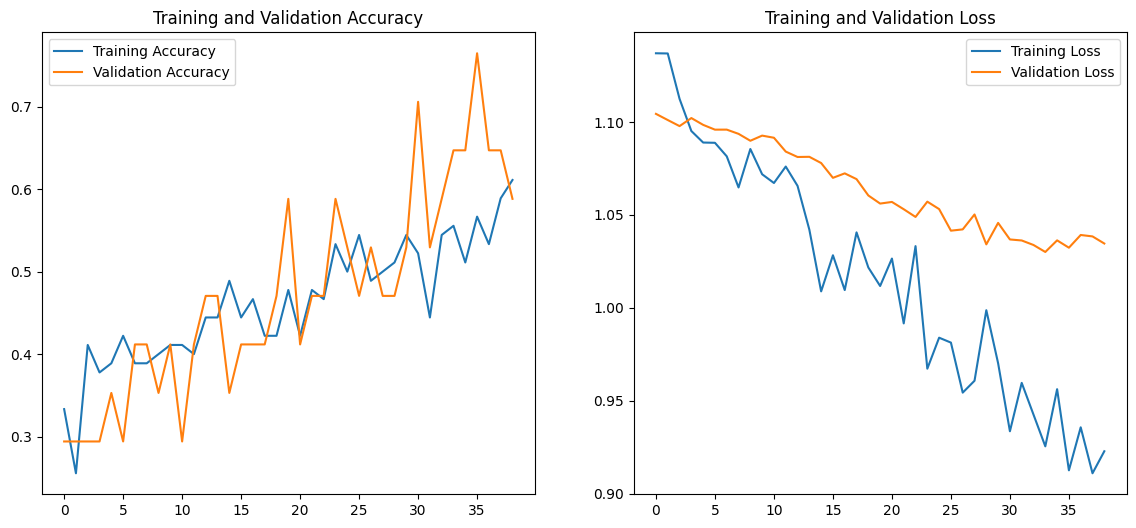

In [ ]:
# Plot training metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
cnn_model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step - accuracy: 0.6667 - loss: 1.0562


[1.0562132596969604, 0.6666666865348816]

In [ ]:
y_pred_prob = cnn_model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test

print(classification_report(
    y_true,
    y_pred,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       0.75      0.75      0.75         4
           2       1.00      0.25      0.40         4

    accuracy                           0.67        12
   macro avg       0.77      0.67      0.63        12
weighted avg       0.77      0.67      0.63        12



# 2) Transfer Learning:-

In [21]:
# Load pretrained EfficientNetB0 (ImageNet)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

In [22]:
# Build final model
tl_model = models.Sequential()

tl_model.add(base_model)
tl_model.add(layers.GlobalAveragePooling2D())
tl_model.add(layers.BatchNormalization())

tl_model.add(layers.Dense(64, activation='relu'))
tl_model.add(layers.Dropout(0.4))


tl_model.add(layers.Dense(3, activation='softmax'))

In [23]:
tl_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
history_tl = tl_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30

Epoch 1: val_loss improved from inf to 0.97147, saving model to rice_leaf_best_model.keras
6/6 - 61s - 10s/step - accuracy: 0.3667 - loss: 2.0928 - val_accuracy: 0.5882 - val_loss: 0.9715 - learning_rate: 1.0000e-04
Epoch 2/30

Epoch 2: val_loss improved from 0.97147 to 0.92911, saving model to rice_leaf_best_model.keras
6/6 - 2s - 336ms/step - accuracy: 0.5000 - loss: 1.5167 - val_accuracy: 0.5882 - val_loss: 0.9291 - learning_rate: 1.0000e-04
Epoch 3/30

Epoch 3: val_loss improved from 0.92911 to 0.88984, saving model to rice_leaf_best_model.keras
6/6 - 3s - 426ms/step - accuracy: 0.4444 - loss: 1.7499 - val_accuracy: 0.5882 - val_loss: 0.8898 - learning_rate: 1.0000e-04
Epoch 4/30

Epoch 4: val_loss improved from 0.88984 to 0.85398, saving model to rice_leaf_best_model.keras
6/6 - 2s - 282ms/step - accuracy: 0.4444 - loss: 1.6423 - val_accuracy: 0.5882 - val_loss: 0.8540 - learning_rate: 1.0000e-04
Epoch 5/30

Epoch 5: val_loss improved from 0.85398 to 0.81598, saving mo

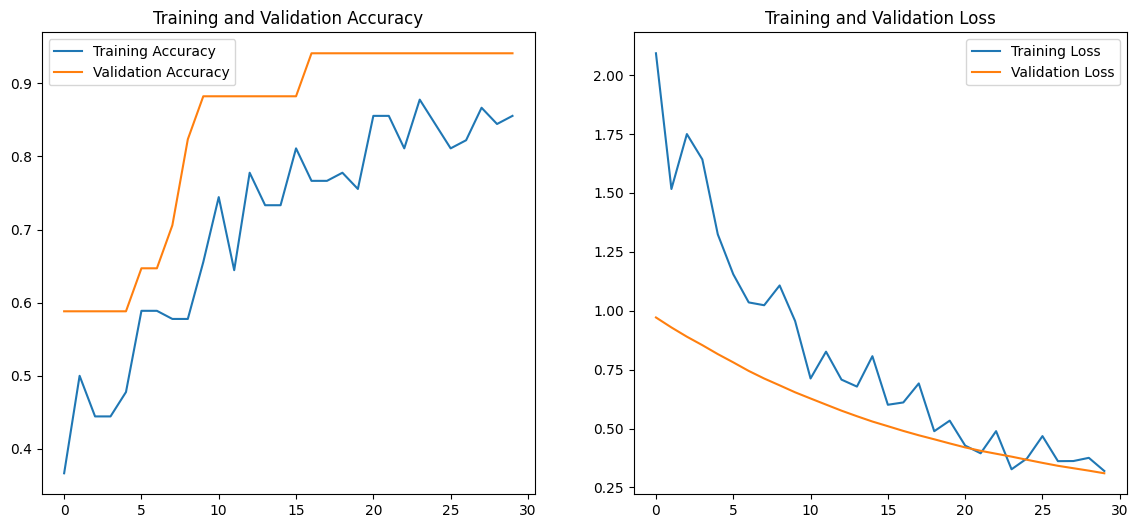

In [28]:
# Plot training metrics
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [25]:
X_test_eff = preprocess_input(x_test.copy())

test_loss, test_acc = tl_model.evaluate(X_test_eff, y_test, verbose=2)
print("Test Accuracy:", test_acc)


1/1 - 10s - 10s/step - accuracy: 0.9167 - loss: 0.3158
Test Accuracy: 0.9166666865348816


In [26]:
y_pred_prob = tl_model.predict(X_test_eff)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.75      0.86         4
           2       0.80      1.00      0.89         4

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

